In [2]:
!pip install librosa scipy matplotlib numpy --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Сглаживание временных рядов

In [3]:
import requests
from io import BytesIO
import numpy as np

resp = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts1.npy?download=1")
resp.raise_for_status()
series_x = np.load(BytesIO(resp.content))
print(len(series_x))

resp = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts4_4.npy?download=1")
resp.raise_for_status()
series_y = np.load(BytesIO(resp.content))
print(len(series_y))

144
1000


# _______________________________________________________________________________________________________

In [4]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [11, 7]
plt.rcParams['figure.dpi'] = 100

resp = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts1.npy?download=1")
series_x = np.load(BytesIO(resp.content))

resp = requests.get("https://zenodo.org/records/10897398/files/smoothing_ts4_4.npy?download=1")
series_y = np.load(BytesIO(resp.content))

print(len(series_x), len(series_y))

144 1000


Создаём временные оси, начиная с нуля

In [5]:
t1 = np.arange(len(series_x))
t2 = np.arange(len(series_y))

Разделение на train/test. Последние 5 точек это тест.

In [6]:
train_x, test_x = series_x[:-5], series_x[-5:]
train_y, test_y = series_y[:-5], series_y[-5:]

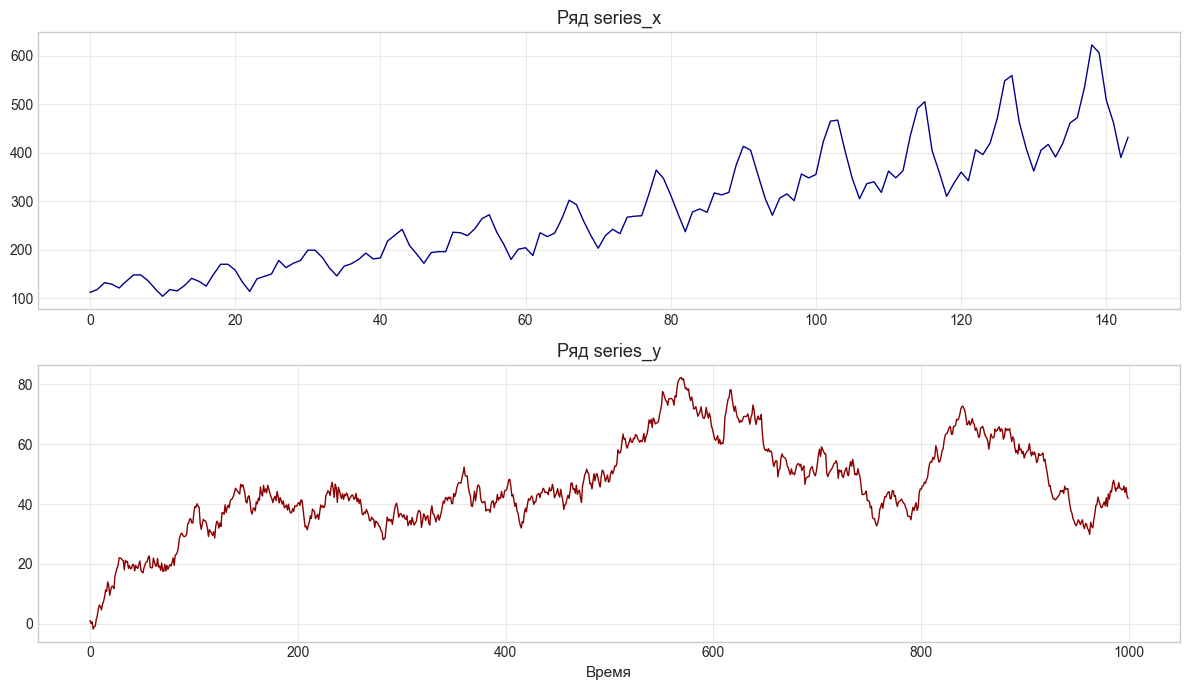

In [7]:
def calc_mse(actual, predicted):
    assert len(actual) == len(predicted)
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(t1, series_x, color='darkblue', linewidth=1.0)
axes[0].set_title('Ряд series_x', fontsize=13)
axes[0].grid(True, alpha=0.4)

axes[1].plot(t2, series_y, color='darkred', linewidth=1.0)
axes[1].set_title('Ряд series_y', fontsize=13)
axes[1].set_xlabel('Время', fontsize=11)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Ряд series_x демонстрирует линейный восходящий тренд без выраженной сезонности. Колебания вокруг тренда случайны.

Ряд series_y содержит тренд и периодические сезонные колебания. Необходимо определить тип сезонности.

#### Декомпозиция

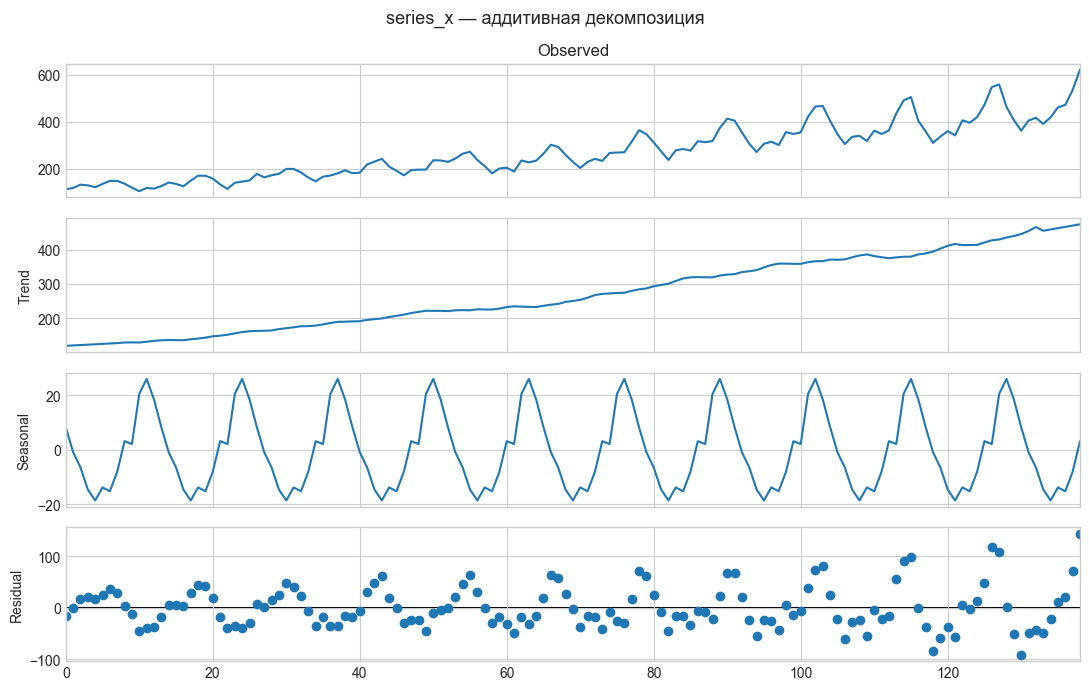

In [8]:
dec_x = seasonal_decompose(train_x, model='additive', period=13, extrapolate_trend='freq')
dec_x.plot()
plt.suptitle('series_x — аддитивная декомпозиция', fontsize=13)
plt.tight_layout()
plt.show()

series_x: аддитивный тренд + аддитивная сезонность + шум.

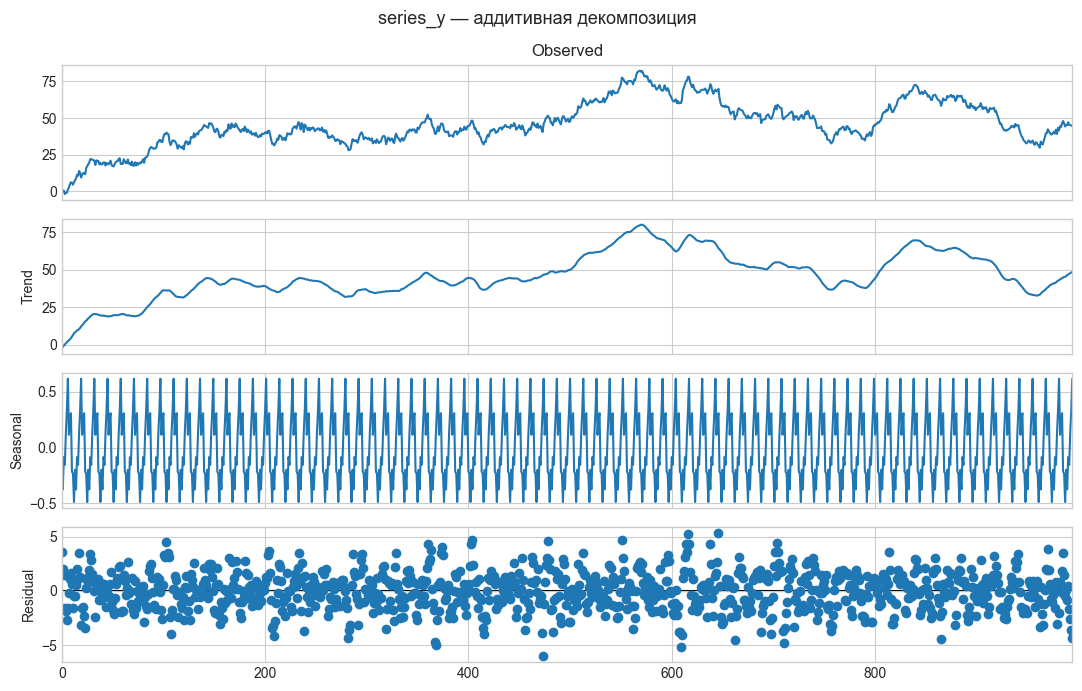

In [9]:
dec_y = seasonal_decompose(train_y, model='additive', period=13, extrapolate_trend='freq')
dec_y.plot()
plt.suptitle('series_y — аддитивная декомпозиция', fontsize=13)
plt.tight_layout()
plt.show()

series_y: нелинейный тренд + аддитивная сезонность. Мультипликативная модель неприменима из-за нулевых значений в ряде.

#### Построение моделей

In [10]:
mdl_x = Holt(train_x).fit(optimized=True)
forecast_x = mdl_x.forecast(5)
err_x = calc_mse(test_x, forecast_x)
print(f"series_x — Holt (двойное сглаживание) MSE: {err_x:.4f}")
print(f"  alpha={mdl_x.params['smoothing_level']:.4f}, "
      f"beta={mdl_x.params['smoothing_trend']:.4f}")

series_x — Holt (двойное сглаживание) MSE: 32467.3996
  alpha=1.0000, beta=0.0000


In [11]:
mdl_y = ExponentialSmoothing(
    train_y,
    trend='additive',
    seasonal='additive',
    seasonal_periods=13
).fit(optimized=True)

forecast_y = mdl_y.forecast(5)
err_y = calc_mse(test_y, forecast_y)
print(f"series_y — Holt-Winters (тройное сглаживание) MSE: {err_y:.4f}")
print(f"  alpha={mdl_y.params['smoothing_level']:.4f}, "
      f"beta={mdl_y.params['smoothing_trend']:.4f}, "
      f"gamma={mdl_y.params['smoothing_seasonal']:.4f}")

series_y — Holt-Winters (тройное сглаживание) MSE: 2.2796
  alpha=1.0000, beta=0.0000, gamma=0.0000


Модель Holt для series_x показала вырожденное решение (alpha=1, beta=0) с высокой ошибкой MSE. Для этого ряда нужен другой подход. series_y прогнозируется точно с MSE=2.28.

График series_x

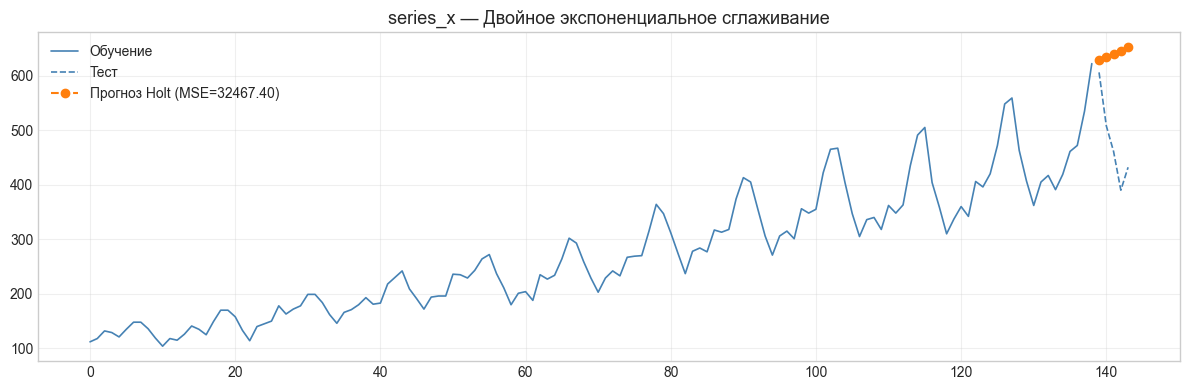

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t1[:-5], train_x, label='Обучение', color='steelblue', linewidth=1.2)
ax.plot(t1[-5:], test_x, label='Тест', color='steelblue', linestyle='--', linewidth=1.2)
ax.plot(t1[-5:], forecast_x, label=f'Прогноз Holt (MSE={err_x:.2f})',
        color='tab:orange', linestyle='--', marker='o', markersize=6)
ax.set_title('series_x — Двойное экспоненциальное сглаживание', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Модель Holt не смогла корректно уловить тренд series_x...

График series_y

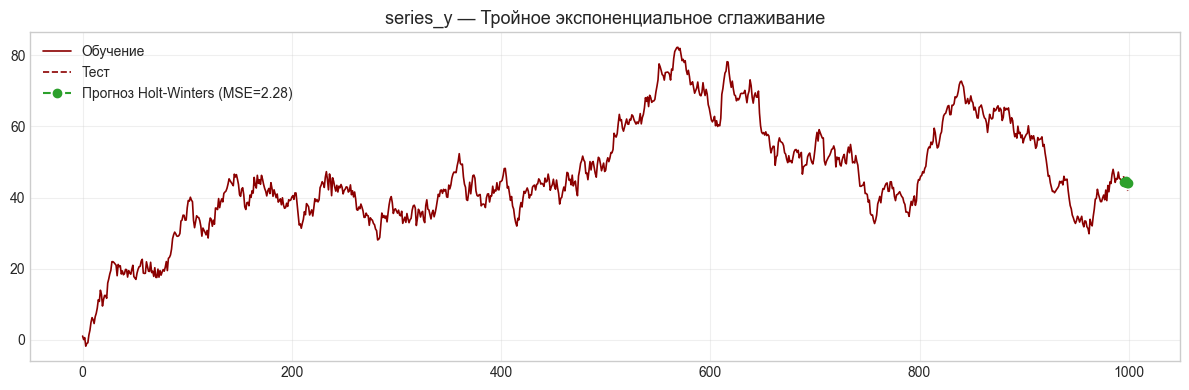

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t2[:-5], train_y, label='Обучение', color='darkred', linewidth=1.2)
ax.plot(t2[-5:], test_y, label='Тест', color='darkred', linestyle='--', linewidth=1.2)
ax.plot(t2[-5:], forecast_y, label=f'Прогноз Holt-Winters (MSE={err_y:.2f})',
        color='tab:green', linestyle='--', marker='o', markersize=6)
ax.set_title('series_y — Тройное экспоненциальное сглаживание', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Тройное экспоненциальное сглаживание хорошо работает для series_y благодаря выраженной сезонности и тренду. Аддитивная модель оправдана амплитуда колебаний не растёт пропорционально уровню ряда.